In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from anndata import AnnData
import matplotlib.pyplot as plt

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()

In [2]:
wt_data_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/wildtype_injection/chimera-wt/raw_counts.mtx"
wt_genes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/wildtype_injection/chimera-wt/genes.tsv"
wt_meta_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/wildtype_injection/chimera-wt/meta.csv" # contains QC performed by Mlnt

out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/wildtype_injection/chimera-wt/"

In [3]:
adata = ad.read_mtx(wt_data_in)


In [4]:
adata_wt = sc.read("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/wildtype_injection/chimera-wt/adata_wt.h5")

TypeError: __init__() got an unexpected keyword argument 'attrs'

In [6]:
adata.X.T

<13481x29453 sparse matrix of type '<class 'numpy.float32'>'
	with 63842193 stored elements in Compressed Sparse Column format>

In [13]:
#do the tranpose because observations and variables seem to be reversed and poses problems downstream
adata = sc.AnnData(adata.X.T)

In [14]:
adata.var

""
0
1
2
3
4
...
29448
29449
29450
29451


In [15]:
genes = pd.read_csv(wt_genes_in, header=None, sep='\t')
adata.var['gene_ids'] = genes[0].values
adata.var['gene_symbols'] = genes[1].values
adata.var_names = adata.var['gene_symbols']
# Make sure the gene names are unique
adata.var_names_make_unique(join="-")

In [20]:
meta = pd.read_csv(wt_meta_in, sep=',')
adata.obs['barcode'] = meta['barcode'].values
adata.obs['sample'] = meta['sample'].values
adata.obs['stage'] = meta['stage'].values
adata.obs['tdTom'] = meta['tomato'].values
adata.obs['stage.mapped'] = meta['stage.mapped'].values
adata.obs['celltype.mapped'] = meta['celltype.mapped'].values
adata.obs['doublet.density'] = meta['doub.density'].values
adata.obs_names = meta['cell']
# Make sure the cell names are unique
adata.obs_names_make_unique(join="-")

In [27]:
adata.obs_names = list(meta['cell'])
adata.obs = meta

In [26]:
meta

,cell,barcode,sample,stage,tomato,stage.mapped,celltype.mapped,doub.density
0,cell_1,AAACCTGAGACCTTTG,1,E7.5,True,E7.5,Haematoendothelial progenitors,0.677768
1,cell_2,AAACCTGAGCGCCTCA,1,E7.5,True,E7.75,Mesenchyme,0.429707
2,cell_3,AAACCTGAGGATCGCA,1,E7.5,True,E7.0,Primitive Streak,0.552286
3,cell_4,AAACCTGCACGTAAGG,1,E7.5,True,E7.75,Caudal epiblast,0.130337
4,cell_5,AAACCTGCAGACAGGT,1,E7.5,True,E7.5,Caudal Mesoderm,0.947504
...,...,...,...,...,...,...,...,...
13476,cell_13477,TTTGGTTGTGATGCCC,6,E8.5,False,E7.5,Stripped,0.000000
13477,cell_13478,TTTGGTTTCGCTTAGA,6,E8.5,False,E8.5,Erythroid3,0.002529
13478,cell_13479,TTTGTCAAGACAATAC,6,E8.5,False,E8.5,Erythroid3,0.166116
13479,cell_13480,TTTGTCAAGGTAGCTG,6,E8.5,False,E8.5,Erythroid3,0.199198


In [28]:
adata.obs

,cell,barcode,sample,stage,tomato,stage.mapped,celltype.mapped,doub.density
0,cell_1,AAACCTGAGACCTTTG,1,E7.5,True,E7.5,Haematoendothelial progenitors,0.677768
1,cell_2,AAACCTGAGCGCCTCA,1,E7.5,True,E7.75,Mesenchyme,0.429707
2,cell_3,AAACCTGAGGATCGCA,1,E7.5,True,E7.0,Primitive Streak,0.552286
3,cell_4,AAACCTGCACGTAAGG,1,E7.5,True,E7.75,Caudal epiblast,0.130337
4,cell_5,AAACCTGCAGACAGGT,1,E7.5,True,E7.5,Caudal Mesoderm,0.947504
...,...,...,...,...,...,...,...,...
13476,cell_13477,TTTGGTTGTGATGCCC,6,E8.5,False,E7.5,Stripped,0.000000
13477,cell_13478,TTTGGTTTCGCTTAGA,6,E8.5,False,E8.5,Erythroid3,0.002529
13478,cell_13479,TTTGTCAAGACAATAC,6,E8.5,False,E8.5,Erythroid3,0.166116
13479,cell_13480,TTTGTCAAGGTAGCTG,6,E8.5,False,E8.5,Erythroid3,0.199198


In [32]:
np.max(adata.X.todense())
#need to normalize and log transform

7926.0

In [33]:
sc.pp.filter_cells(adata, min_genes=0)
sc.pp.filter_genes(adata, min_cells=0)

2021-03-05 13:52:35,401 [169335] WARNING  py.warnings:110: [JupyterRequire] /usr/local/lib/python3.7/dist-packages/anndata/_core/anndata.py:119: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)



In [35]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

... storing 'barcode' as categorical
... storing 'stage' as categorical
... storing 'stage.mapped' as categorical
... storing 'celltype.mapped' as categorical
... storing 'gene_symbols' as categorical


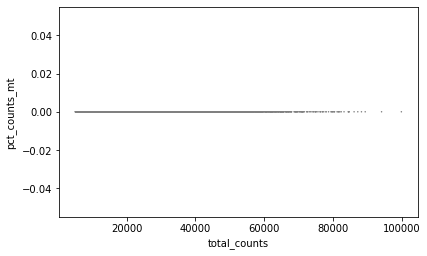

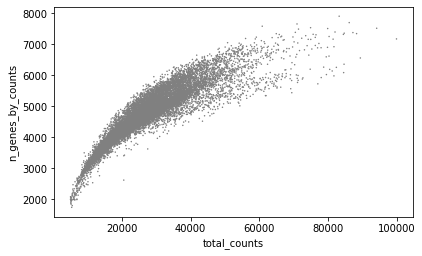

In [36]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

In [38]:
sc.pp.normalize_total(adata, target_sum=1e4)

normalizing counts per cell
    finished (0:00:00)


In [40]:
sc.pp.log1p(adata)

In [52]:
 adata.obs_names = adata.obs.cell

In [57]:
np.unique(adata.obs['celltype.mapped'])

array(['Allantois', 'Anterior Primitive Streak', 'Blood progenitors 1',
       'Blood progenitors 2', 'Cardiomyocytes', 'Caudal Mesoderm',
       'Caudal epiblast', 'Caudal neurectoderm', 'Def. endoderm',
       'Doublet', 'Endothelium', 'Epiblast', 'Erythroid1', 'Erythroid2',
       'Erythroid3', 'ExE ectoderm', 'ExE endoderm', 'ExE mesoderm',
       'Forebrain/Midbrain/Hindbrain', 'Gut',
       'Haematoendothelial progenitors', 'Intermediate mesoderm',
       'Mesenchyme', 'Mixed mesoderm', 'NMP', 'Nascent mesoderm',
       'Neural crest', 'Notochord', 'PGC', 'Paraxial mesoderm',
       'Parietal endoderm', 'Pharyngeal mesoderm', 'Primitive Streak',
       'Rostral neurectoderm', 'Somitic mesoderm', 'Spinal cord',
       'Stripped', 'Surface ectoderm', 'Visceral endoderm'], dtype=object)

In [58]:
adata.write(out_folder + 'adata_wt.h5')

RuntimeError: Unable to create link (name already exists)

Above error raised while writing key 'cell' of <class 'h5py._hl.group.Group'> from /.

Above error raised while writing key 'obs' of <class 'h5py._hl.files.File'> from /.

In [4]:
adata

NameError: name 'adata' is not defined

In [3]:
sc.read_loom('/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/wildtype_injection/chimera-wt/adata_wt.h5')

AnnData object with n_obs × n_vars = 13481 × 29453
    obs: 'barcode', 'cell', 'celltype.mapped', 'doub.density', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'sample', 'stage', 'stage.mapped', 'tomato', 'total_counts', 'total_counts_mt'
    var: 'gene_ids', 'gene_symbols', 'mean_counts', 'mt', 'n_cells', 'n_cells_by_counts', 'pct_dropout_by_counts', 'total_counts'